[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025, Petr Krysl, pkrysl@ucsd.edu

# Example of a frame with a hinge

## Problem description

Portal frame with a hinge at the top of the left column. The frame is loaded
with a sideways force.

Displacements and internal forces are provided in the book, and we can check our
solution against these reference values.

## References

This example is completely solved in the book Matrix Analysis of Structures by
Robert E. Sennett, ISBN 978-1577661436. Example 7.4.


## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)

In [24]:
from numpy.linalg import norm
import context
from pystran import model
from pystran import section
from pystran import plots

US customary units, inches, pounds, seconds are assumed.

The book gives the product of the modulus of elasticity and the moment of
inertia as 2.9e6.


In [25]:
E = 29e6
I = 100.0
A = 10.0  # cross-sectional area does not influence the results
L = 10 * 12  # span in inches

In [26]:
m = model.create(2)
freedoms = m["freedoms"]

First we create the four joints given in the textbook.


In [27]:
model.add_joint(m, 1, [0.0, 0.0])
model.add_joint(m, 2, [0, L])
model.add_joint(m, 3, [L, L])
model.add_joint(m, 4, [L, 0.0])

{'jid': 4, 'coordinates': array([120.,   0.])}

There needs to be a hinge (not transferring bending moments, but ensuring
continuity of displacements) at the joint 2. We add another joint, 5, at the
same location, and we link the degrees of freedom that needs to be the same.


In [28]:

model.add_joint(m, 5, [0, L])

{'jid': 5, 'coordinates': array([  0., 120.])}

We supply the list of joints that need to be linked (2 and 5), and the
degrees of freedom that are to be the same.


In [29]:
model.add_dof_links(m, [2, 5], freedoms.U1)
model.add_dof_links(m, [2, 5], freedoms.U2)

Now we apply the supports -- both bottom joints are simply supported
(pinned).


In [30]:
model.add_support(m["joints"][1], freedoms.TRANSLATION_DOFS)
model.add_support(m["joints"][4], freedoms.TRANSLATION_DOFS)

Define the beam members.


In [31]:
s1 = section.beam_2d_section("s1", E, A, I)
model.add_beam_member(m, 1, [1, 2], s1)
model.add_beam_member(m, 2, [5, 3], s1)
model.add_beam_member(m, 3, [4, 3], s1)

{'mid': 3,
 'connectivity': [4, 3],
 'section': {'name': 's1',
  'E': 29000000.0,
  'rho': 0.0,
  'CTE': 0.0,
  'A': 10.0,
  'I': 100.0}}

Sideload is applied at joint 2.


In [32]:
model.add_load(m["joints"][2], freedoms.U1, 1000.0)

The discrete model can now be reviewed. Note the orientations of the local
coordinate systems.


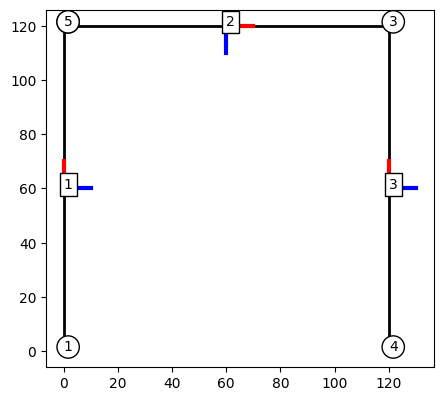

In [33]:
plots.setup(m)
plots.plot_members(m)
plots.plot_member_ids(m)
plots.plot_joint_ids(m)
plots.plot_member_orientation(m, 10.0)
plots.show(m)

Solve the discrete model.


In [34]:
model.number_dofs(m)
model.solve_statics(m)

First check of the solution is the plot of the deformation.


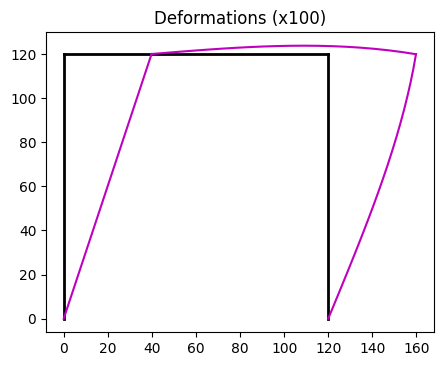

In [35]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_deformations(m, 100.0)
ax.set_title("Deformations (x100)")
plots.show(m)

The displacements at the movable joints are printed out.


In [36]:
for jid in [2, 3]:
    j = m["joints"][jid]
    print(jid, j["displacements"])

2 [ 0.39848276  0.00041379 -0.00332069]
3 [ 0.39806897 -0.00041379 -0.00166207]


The displacements at the hinge joints are compared to each other: the
translations should be identical.


In [37]:
d2 = m["joints"][2]["displacements"]
d5 = m["joints"][5]["displacements"]
if norm(d2[0:2] - d5[0:2]) > 1e-3:
    raise ValueError("Incorrect displacement")

The displacements at the hinge are compared to the reference values from the
textbook.


In [38]:
if abs(d2[0] - 0.3985) / 0.3985 > 1e-3:
    raise ValueError("Incorrect displacement")
if abs(d2[1] - 0.00041) / 0.00041 > 1e-2:
    raise ValueError("Incorrect displacement")

The obligatory diagrams of bending moments and shear forces follow.


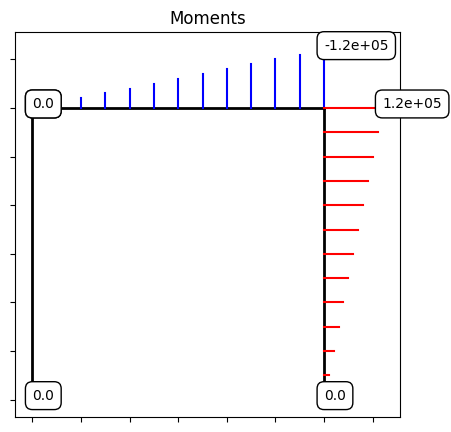

In [39]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_bending_moments(m)
ax.set_title("Moments")
plots.show(m)

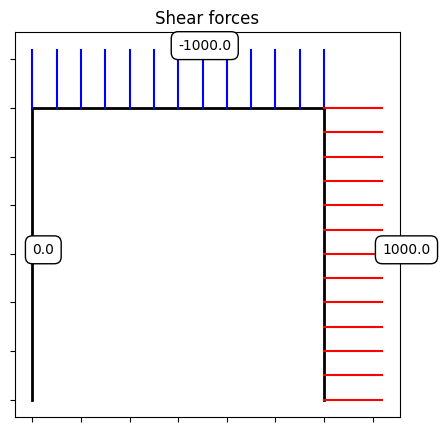

In [40]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_shear_forces(m)
ax.set_title("Shear forces")
plots.show(m)